In [6]:
### Luobin Wang ###
### Resubmission ###

In [7]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

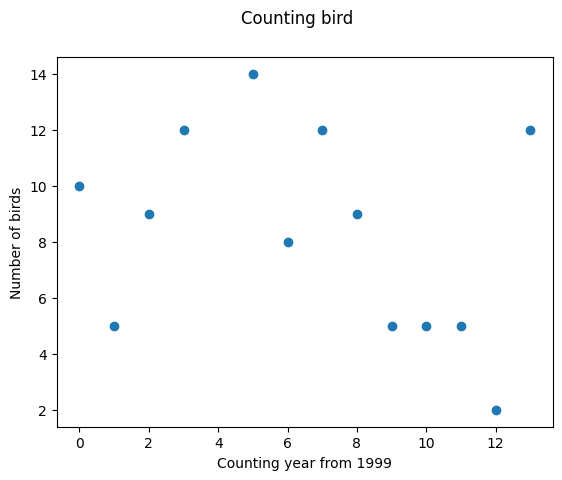

<class 'list'> <class 'int'>


In [8]:
# Read the CSV file
x_yr = []
y_count = []
with open('bird_count.csv','r',encoding = "utf-8") as f:
    birdfile = csv.reader(f)
    next(birdfile)
    for row in birdfile:
        c = int(row[0])
        yr = int(row[1])-1999
        x_yr.append(yr)
        y_count.append(c)

    fig,ax = plt.subplots()
    fig.suptitle('Counting bird')
    ax.scatter(x_yr, y_count)
    ax.set_ylabel('Number of birds')
    ax.set_xlabel('Counting year from 1999')
    plt.show()
print(type(x_yr),type(yr))

In [9]:
def poisson_dis (param, x, y):
    beta0,beta1 = param[0],param[1]
    log_lamda = beta0+beta1* np.array(x)
    log_llh = np.sum((-np.exp(log_lamda))+(log_lamda)*np.array(y)) #here factorial y not contain parameters, likelyhood can be optimized without term y
    return -log_llh

'''beta0 and beta1 are parameters have to be optimized to maximum the likelihood
In this case, minimizing the -log_llh can be applied
Start from beta0 and beta1 are both 0'''

initial_theta = [0,0]
est = minimize(poisson_dis, initial_theta, args=(x_yr,y_count))
theta_est = est.x
beta0_est,beta1_est = theta_est[0],theta_est[1]

print(f'Estimated beta0:{beta0_est: .4f}',f'Estimated beta1:{beta1_est: .4f}')

Estimated beta0: 2.3253 Estimated beta1:-0.0324


In [10]:
# Making predictions 
lam_pre = np.exp(beta0_est+beta1_est*np.array(x_yr))
pre_1 = np.random.poisson(lam_pre)
pre_2 = np.random.poisson(lam_pre)
pre_3 = np.random.poisson(lam_pre)

if len(x_yr)>0 and isinstance(x_yr[0],list):
    x_yr = x_yr[0]

output_file = "bird_count_prediction.csv"
with open(output_file,'w',newline = '', encoding = "utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(['year', 'prediction_1','prediction_2','prediction_3'])
    for x, p1, p2, p3 in zip(x_yr, pre_1, pre_2, pre_3):
        year = x+1999
        writer.writerow([year, p1, p2, p3])

print(output_file)

bird_count_prediction.csv
